In [3]:
# ============================================================
# CLEAN PPE DATASET FOR CONTEXT-AWARE SAFETY SYSTEM
# ============================================================
#
# PURPOSE:
# - Remove weak "NO-*" classes
# - Remap labels
# - Create cleaner YOLO dataset
# - Generate data.yaml automatically
#
# FINAL CLASSES:
# 0 -> Hardhat
# 1 -> Mask
# 2 -> Person
# 3 -> Safety Cone
# 4 -> Safety Vest
# 5 -> machinery
# 6 -> vehicle
#
# ============================================================

from pathlib import Path
import shutil
from tqdm import tqdm
import yaml

# ============================================================
# ROOT PATHS
# ============================================================

PROJECT_ROOT = Path("../")

SOURCE_DATASET = (
    PROJECT_ROOT / "datasets" / "raw" / "css-data")

CLEAN_DATASET = (
    PROJECT_ROOT / "datasets" / "processed" / "dataset_final")

# ============================================================
# CLASS REMAPPING
# ============================================================

# ORIGINAL CLASSES:
#
# 0 -> Hardhat
# 1 -> Mask
# 2 -> NO-Hardhat
# 3 -> NO-Mask
# 4 -> NO-Safety Vest
# 5 -> Person
# 6 -> Safety Cone
# 7 -> Safety Vest
# 8 -> machinery
# 9 -> vehicle

CLASS_MAPPING = {

    0: 0,   # Hardhat
    1: 1,   # Mask
    5: 2,   # Person
    6: 3,   # Safety Cone
    7: 4,   # Safety Vest
    8: 5,   # machinery
    9: 6    # vehicle
}

# ============================================================
# FINAL CLASS NAMES
# ============================================================

CLASS_NAMES = [

    "Hardhat",
    "Mask",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle"
]

# ============================================================
# CREATE DIRECTORY STRUCTURE
# ============================================================

splits = ["train", "valid", "test"]

for split in splits:

    # Create image folder
    (CLEAN_DATASET / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    # Create label folder
    (CLEAN_DATASET / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# PROCESS DATASET
# ============================================================

for split in splits:

    image_src = SOURCE_DATASET / split / "images"
    label_src = SOURCE_DATASET / split / "labels"

    image_dst = CLEAN_DATASET / split / "images"
    label_dst = CLEAN_DATASET / split / "labels"

    label_files = list(label_src.glob("*.txt"))

    for label_file in tqdm(
    label_files,
    desc=f"{split.upper()}",
    leave=False):

        new_lines = []

        # ----------------------------------------------------
        # READ LABEL FILE
        # ----------------------------------------------------

        with open(label_file, "r") as f:
            lines = f.readlines()

        # ----------------------------------------------------
        # PROCESS EACH LABEL
        # ----------------------------------------------------

        for line in lines:

            parts = line.strip().split()

            # Skip invalid annotations
            if len(parts) < 5:
                continue

            class_id = int(parts[0])

            # Skip removed classes
            if class_id not in CLASS_MAPPING:
                continue

            # Remap class
            new_class_id = CLASS_MAPPING[class_id]

            # Replace class ID
            parts[0] = str(new_class_id)

            # Save remapped annotation
            new_lines.append(" ".join(parts))

        # ----------------------------------------------------
        # SKIP EMPTY LABEL FILES
        # ----------------------------------------------------

        if len(new_lines) == 0:
            continue

        # ----------------------------------------------------
        # SAVE NEW LABEL FILE
        # ----------------------------------------------------

        output_label_path = label_dst / label_file.name

        with open(output_label_path, "w") as f:
            f.write("\n".join(new_lines))

        # ----------------------------------------------------
        # COPY CORRESPONDING IMAGE
        # ----------------------------------------------------

        image_found = False

        image_extensions = [
            ".jpg",
            ".jpeg",
            ".png"
        ]

        for ext in image_extensions:

            image_path = image_src / f"{label_file.stem}{ext}"

            if image_path.exists():

                shutil.copy(
                    image_path,
                    image_dst / image_path.name
                )

                image_found = True
                break

        # ----------------------------------------------------
        # REPORT MISSING IMAGE
        # ----------------------------------------------------

        if not image_found:
            print(f"Missing image for: {label_file.name}")

# ============================================================
# CREATE data.yaml
# ============================================================

yaml_data = {

    # Relative dataset path
    "path": "../datasets/processed/dataset_final",

    "train": "train/images",

    "val": "valid/images",

    "test": "test/images",

    "names": CLASS_NAMES
}

# ============================================================
# SAVE YAML TO CONFIGS
# ============================================================

CONFIG_DIR = ROOT / "configs"

CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

yaml_path = CONFIG_DIR / "data.yaml"

with open(yaml_path, "w") as f:

    yaml.dump(
        yaml_data,
        f,
        sort_keys=False
    )

# ============================================================
# DATASET SUMMARY
# ============================================================

print(f"\n{'='*60}")
print("DATASET SUMMARY")
print(f"{'='*60}")

for split in splits:

    image_count = len(
        list((CLEAN_DATASET / split / "images").glob("*"))
    )

    label_count = len(
        list((CLEAN_DATASET / split / "labels").glob("*"))
    )

    print(f"\n{split.upper()}")
    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")

# ============================================================
# FINAL CLASSES
# ============================================================

print(f"\n{'='*60}")
print("FINAL CLASSES")
print(f"{'='*60}")

for idx, name in enumerate(CLASS_NAMES):

    print(f"{idx} -> {name}")

# ============================================================
# SUCCESS MESSAGE
# ============================================================

print(f"\n{'='*60}")
print("DATASET CLEANING COMPLETED")
print(f"{'='*60}")

print("\nGenerated Artifacts:")

print("✓ Processed YOLO dataset")
print("✓ Remapped annotations")
print("✓ Filtered classes")
print("✓ data.yaml configuration")

print("\nSaved To:")

print("datasets/processed/dataset_final/")
print("configs/data.yaml")


DATASET SUMMARY

TRAIN
Images : 2599
Labels : 2599

VALID
Images : 104
Labels : 104

TEST
Images : 74
Labels : 74

FINAL CLASSES
0 -> Hardhat
1 -> Mask
2 -> Person
3 -> Safety Cone
4 -> Safety Vest
5 -> machinery
6 -> vehicle

DATASET CLEANING COMPLETED

Generated Artifacts:
✓ Processed YOLO dataset
✓ Remapped annotations
✓ Filtered classes
✓ data.yaml configuration

Saved To:
datasets/processed/dataset_final/
configs/data.yaml


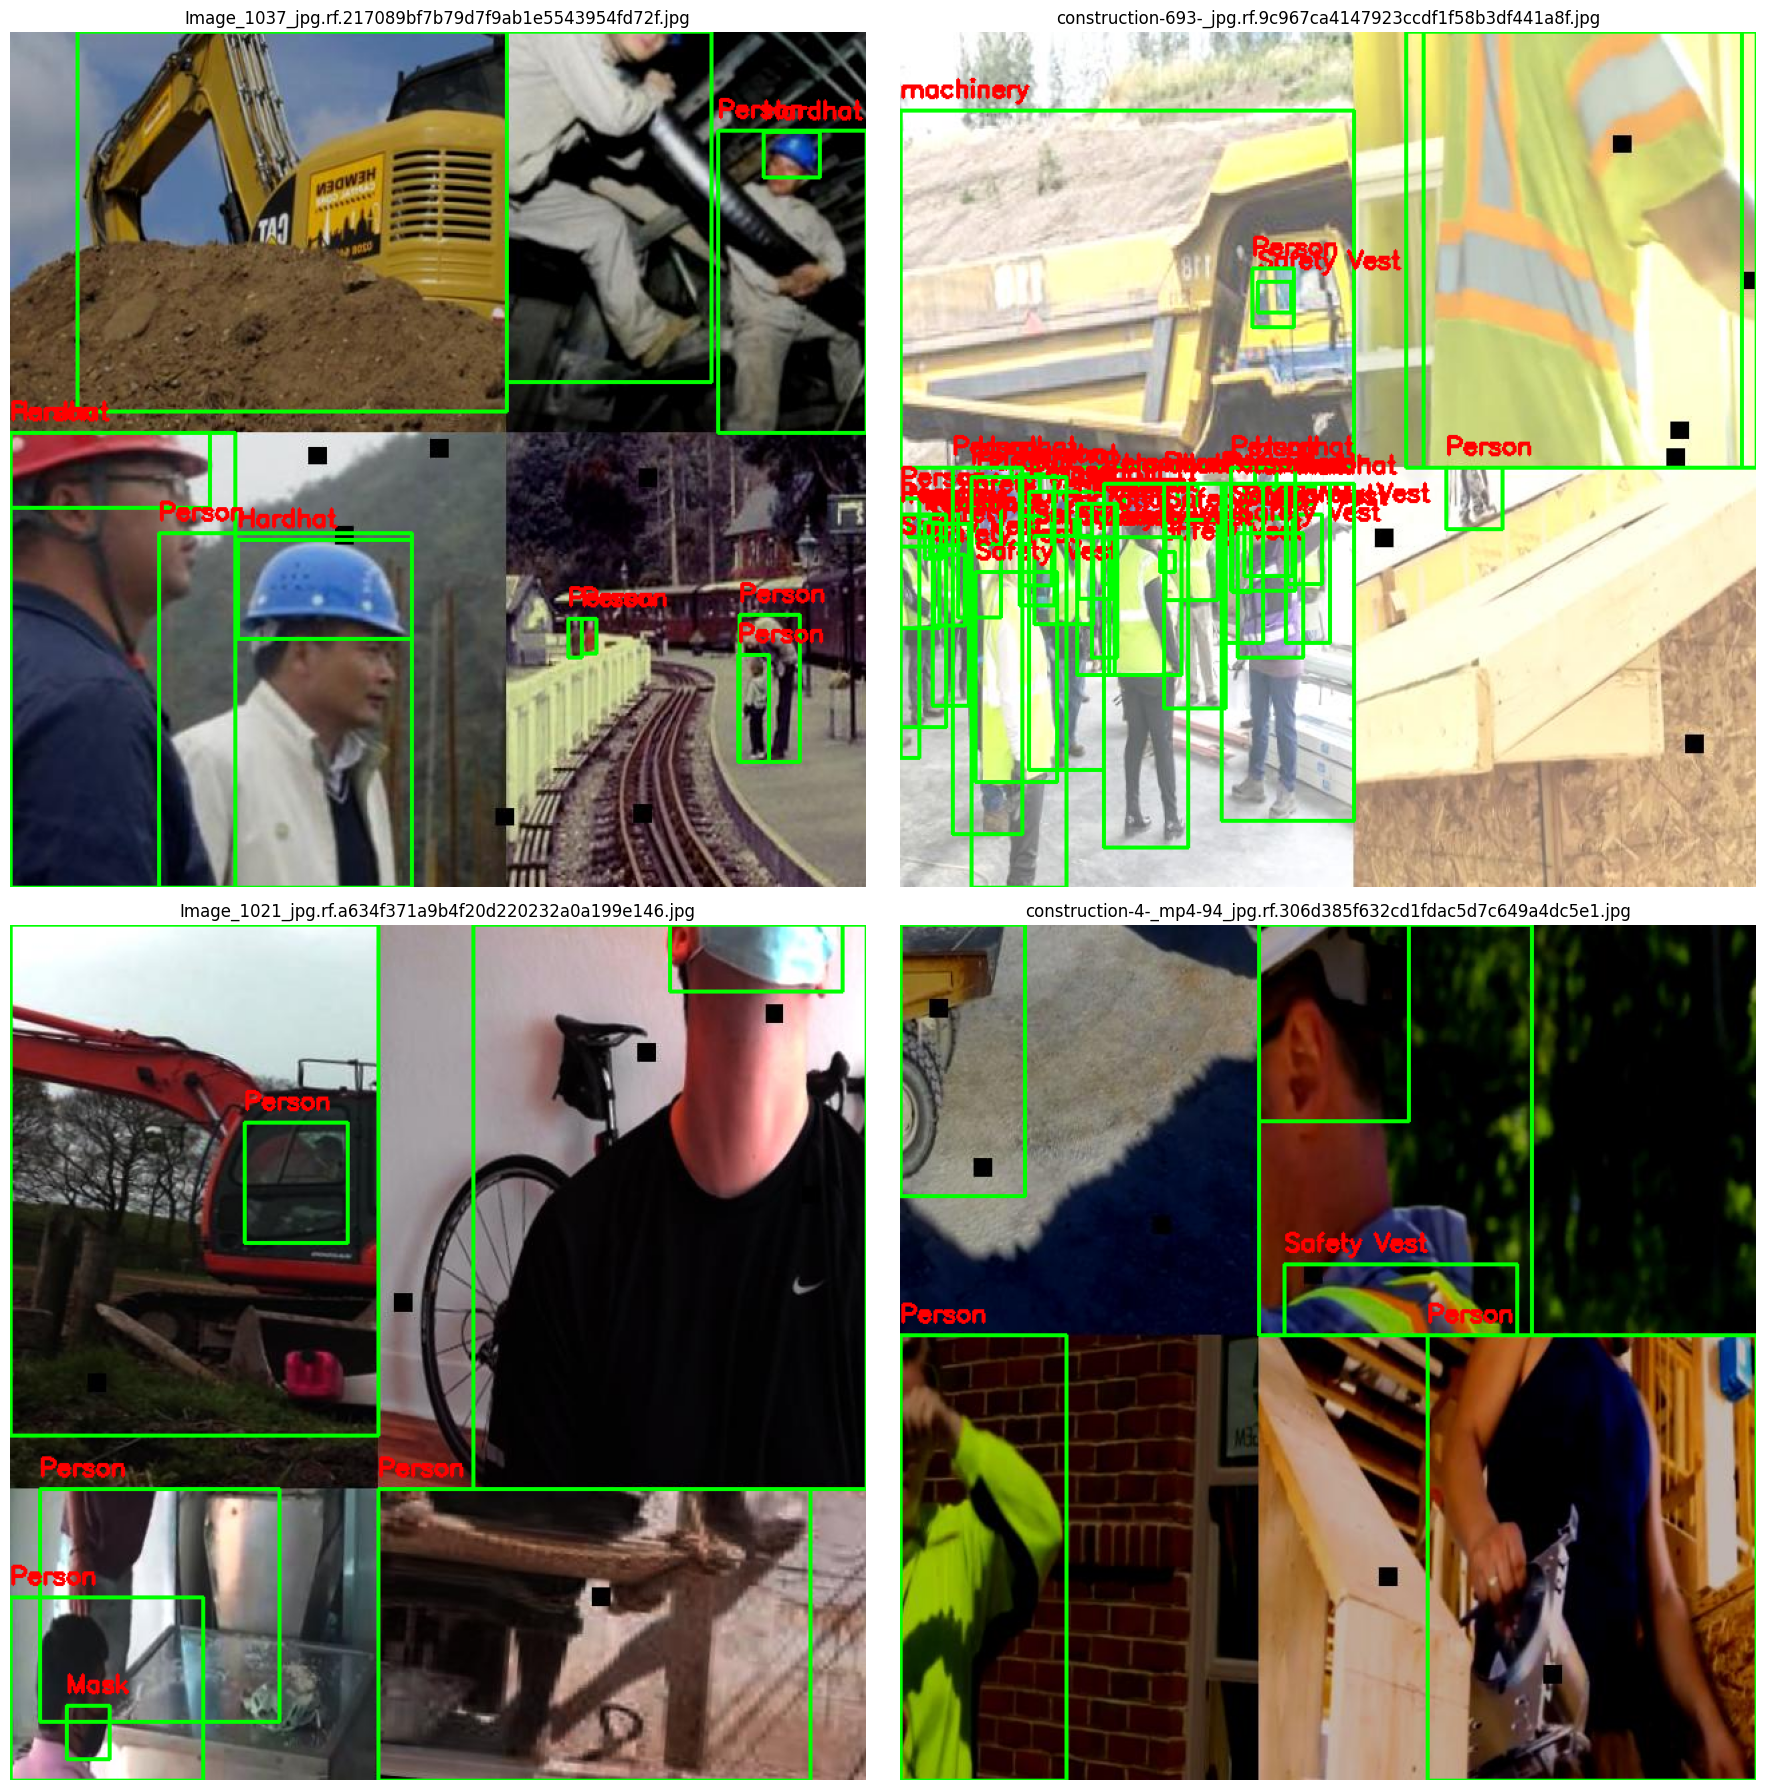

In [5]:
# ============================================================
# VISUALIZE CLEANED DATASET ANNOTATIONS
# ============================================================

import random
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# DATASET PATH
# ============================================================

DATASET_PATH = Path(PROJECT_ROOT / "datasets" / "processed" / "dataset_final")

# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [

    "Hardhat",
    "Mask",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle"
]

# ============================================================
# DIRECTORIES
# ============================================================

image_dir = DATASET_PATH / "train" / "images"
label_dir = DATASET_PATH / "train" / "labels"

# ============================================================
# RANDOM SAMPLE
# ============================================================

sample_images = random.sample(
    list(image_dir.glob("*.jpg")),
    4
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 18))

# ============================================================
# DRAW ANNOTATIONS
# ============================================================

for ax, image_path in zip(axes.flatten(), sample_images):

    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    image = cv2.imread(str(image_path))

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h, w = image.shape[:2]

    # --------------------------------------------------------
    # LOAD LABEL FILE
    # --------------------------------------------------------

    label_path = label_dir / f"{image_path.stem}.txt"

    with open(label_path, "r") as f:
        lines = f.readlines()

    # --------------------------------------------------------
    # DRAW EACH BOX
    # --------------------------------------------------------

    for line in lines:

        parts = line.strip().split()

        class_id = int(parts[0])

        x_center = float(parts[1]) * w
        y_center = float(parts[2]) * h

        box_width = float(parts[3]) * w
        box_height = float(parts[4]) * h

        # Convert YOLO format to corner format
        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)

        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        label = CLASS_NAMES[class_id]

        # ----------------------------------------------------
        # DRAW RECTANGLE
        # ----------------------------------------------------

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # ----------------------------------------------------
        # DRAW LABEL
        # ----------------------------------------------------

        cv2.putText(
            image,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    # --------------------------------------------------------
    # DISPLAY IMAGE
    # --------------------------------------------------------

    ax.imshow(image)

    ax.axis("off")

    ax.set_title(image_path.name)

# ============================================================
# SHOW RESULTS
# ============================================================

plt.tight_layout()

plt.show()